In [73]:
import numpy as np
import yfinance as yf
import talib
import pandas as pd
import warnings
from datetime import date
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')

In [81]:
# FAANG STOCKS
faang_tickers = ['AAPL', 'AMZN', 'NFLX', 'GOOGL', 'META']
period = "10y"

print("=== FAANG STOCK ROBOT ===")

all_data = []

for ticker in faang_tickers:
    try:
        print(f"Processing {ticker}...")
        
        # Download data
        stock_data = yf.download(ticker, period=period, progress=False)
        
        if stock_data.empty:
            print(f"  ❌ No data for {ticker}")
            continue
            
        # Handle multi-index columns properly
        if isinstance(stock_data.columns, pd.MultiIndex):
            # Extract data correctly from multi-index
            close = stock_data['Close'][ticker].values.astype(np.float64)
            high = stock_data['High'][ticker].values.astype(np.float64)
            low = stock_data['Low'][ticker].values.astype(np.float64)
            open_price = stock_data['Open'][ticker].values.astype(np.float64)
            volume = stock_data['Volume'][ticker].values.astype(np.float64)
            
            # Create clean DataFrame for calculations
            df = pd.DataFrame({
                'Open': open_price,
                'High': high,
                'Low': low,
                'Close': close,
                'Volume': volume
            }, index=stock_data.index)
        else:
            # Single stock download
            df = stock_data.copy()
            close = df['Close'].values.astype(np.float64)
            high = df['High'].values.astype(np.float64)
            low = df['Low'].values.astype(np.float64)
            open_price = df['Open'].values.astype(np.float64)
            volume = df['Volume'].values.astype(np.float64)
        
        # Create features DataFrame
        features = pd.DataFrame(index=df.index)
        
        # === PRICE ACTION (12 features) ===
        features['Price_Change'] = df['Close'].pct_change()
        features['High_Low_Ratio'] = df['High'] / df['Low']
        features['Open_Close_Ratio'] = df['Open'] / df['Close']
        features['Close_High_Ratio'] = df['Close'] / df['High']
        features['Close_Low_Ratio'] = df['Close'] / df['Low']
        features['Price_Range'] = (df['High'] - df['Low']) / df['Close']
        features['Gap_Up'] = (df['Open'] / df['Close'].shift(1)) - 1
        features['Intraday_Return'] = (df['Close'] - df['Open']) / df['Open']
        features['Overnight_Return'] = (df['Open'] / df['Close'].shift(1)) - 1
        features['True_Range'] = np.maximum(df['High'] - df['Low'], 
                                           np.maximum(np.abs(df['High'] - df['Close'].shift(1)),
                                                    np.abs(df['Low'] - df['Close'].shift(1))))
        features['Price_Position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 0.001)
        features['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
        
        # === MOMENTUM (10 features) === 
        features['RSI_14'] = talib.RSI(close, timeperiod=14)
        features['RSI_7'] = talib.RSI(close, timeperiod=7)
        features['RSI_21'] = talib.RSI(close, timeperiod=21)
        features['Williams_R'] = talib.WILLR(high, low, close, timeperiod=14)
        features['ROC_5'] = talib.ROC(close, timeperiod=5)
        features['ROC_10'] = talib.ROC(close, timeperiod=10)
        features['ROC_20'] = talib.ROC(close, timeperiod=20)
        features['CCI'] = talib.CCI(high, low, close, timeperiod=14)
        features['Momentum_10'] = talib.MOM(close, timeperiod=10)
        features['Momentum_20'] = talib.MOM(close, timeperiod=20)
        
        # === TREND (10 features) ===
        sma_5 = talib.SMA(close, timeperiod=5)
        sma_10 = talib.SMA(close, timeperiod=10)
        sma_20 = talib.SMA(close, timeperiod=20)
        sma_50 = talib.SMA(close, timeperiod=50)
        ema_9 = talib.EMA(close, timeperiod=9)
        ema_21 = talib.EMA(close, timeperiod=21)
        
        features['SMA_5'] = sma_5
        features['SMA_10'] = sma_10
        features['SMA_20'] = sma_20
        features['Price_vs_SMA20'] = close / sma_20
        features['Price_vs_SMA50'] = close / sma_50
        features['SMA_5_20_Ratio'] = sma_5 / sma_20
        features['EMA_9'] = ema_9
        features['EMA_21'] = ema_21
        features['Price_vs_EMA21'] = close / ema_21
        features['ADX'] = talib.ADX(high, low, close, timeperiod=14)
        
        # === MACD (3 features) ===
        macd_line, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
        features['MACD'] = macd_line
        features['MACD_Signal'] = macd_signal
        features['MACD_Histogram'] = macd_hist
        
        # === VOLATILITY (6 features) ===
        features['ATR_14'] = talib.ATR(high, low, close, timeperiod=14)
        features['ATR_7'] = talib.ATR(high, low, close, timeperiod=7)
        features['Std_10'] = df['Close'].rolling(window=10).std()
        features['Std_20'] = df['Close'].rolling(window=20).std()
        bb_upper, bb_middle, bb_lower = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2)
        features['BB_Position'] = (close - bb_lower) / (bb_upper - bb_lower + 0.001)
        features['BB_Width'] = (bb_upper - bb_lower) / bb_middle
        
        # === VOLUME (7 features) ===
        vol_sma_10 = df['Volume'].rolling(window=10).mean()
        vol_sma_20 = df['Volume'].rolling(window=20).mean()
        features['Volume_SMA_10'] = vol_sma_10
        features['Volume_SMA_20'] = vol_sma_20
        features['Volume_Ratio_10'] = df['Volume'] / (vol_sma_10 + 1)
        features['Volume_Ratio_20'] = df['Volume'] / (vol_sma_20 + 1)
        features['Volume_Change'] = df['Volume'].pct_change()
        features['Price_Volume'] = df['Close'] * df['Volume'] / 1000000
        features['OBV'] = talib.OBV(close, volume)
        
        # Add target and ticker
        features['Target'] = df['Close'].shift(-1)  # Next day's close ## CAN CHANGE THE PRICE TARGET CHANGE (target_days_ahead)
        features['Ticker'] = ticker
        
        # Remove infinite and NaN values
        features = features.replace([np.inf, -np.inf], np.nan)
        
        clean_data = features.dropna()
        
        if len(clean_data) > 0:
            all_data.append(clean_data)
        else:
            print(f"  ⚠️ {ticker}: No clean data after processing")
            
    except Exception as e:
        print(f"  ❌ {ticker}: Error - {str(e)}")

# Combine all data
if all_data:
    ml_data = pd.concat(all_data, ignore_index=True)
    feature_count = len([col for col in ml_data.columns if col not in ['Target', 'Ticker']])
        
    print("=" * 50)
    print("🎯 FAANG ENHANCED DATASET COMPLETE!")
    print("=" * 50)
    print(f"📊 Total samples: {len(ml_data):,}")
    print(f"🔧 Features: {feature_count}")
    print(f"📈 Stocks: {sorted(ml_data['Ticker'].unique())}")
    print(f"💾 Memory: {ml_data.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    print(f"📅 Date range: {period} from now")
    
    # Samples per stock
    print(f"\n📊 SAMPLES PER STOCK:")
    for stock in sorted(ml_data['Ticker'].unique()):
        count = len(ml_data[ml_data['Ticker'] == stock])
        print(f"  {stock}: {count:,} samples")
    
    # Show sample data
    sample_cols = ['Price_Change', 'RSI_14', 'MACD', 'ATR_14', 'Volume_Ratio_10', 'Target', 'Ticker']
    print(f"\n📋 SAMPLE DATA:")
    print(ml_data[sample_cols].head(3).round(4))
    
    print(f"\n✅ Ready for ML with {feature_count} features!")
    
else:
    print("\n❌ ERROR: No data processed successfully!")
    ml_data = pd.DataFrame()

=== FAANG STOCK ROBOT ===
Processing AAPL...
Processing AMZN...
Processing NFLX...
Processing GOOGL...
Processing META...
🎯 FAANG ENHANCED DATASET COMPLETE!
📊 Total samples: 12,325
🔧 Features: 48
📈 Stocks: ['AAPL', 'AMZN', 'GOOGL', 'META', 'NFLX']
💾 Memory: 5.3 MB
📅 Date range: 10y from now

📊 SAMPLES PER STOCK:
  AAPL: 2,465 samples
  AMZN: 2,465 samples
  GOOGL: 2,465 samples
  META: 2,465 samples
  NFLX: 2,465 samples

📋 SAMPLE DATA:
   Price_Change   RSI_14    MACD  ATR_14  Volume_Ratio_10   Target Ticker
0        0.0278  48.1703 -0.5198  0.8926           0.7935  24.7816   AAPL
1       -0.0192  45.0090 -0.4996  0.8971           1.2639  25.3261   AAPL
2        0.0220  49.0439 -0.4347  0.8874           0.9847  25.6950   AAPL

✅ Ready for ML with 48 features!


In [75]:
#Device Detection
import torch

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using Apple Silicon GPU")
else:
    device = torch.device('cpu')
    print("Using CPU")

Using GPU: NVIDIA GeForce RTX 4060


In [76]:
# NEURAL NETWORK ARCHITECTURES FOR STOCK PREDICTION
print("🧠 BUILDING NEURAL NETWORK ARCHITECTURES")
print("=" * 45)

i_features=53

class StockPredictorNN(nn.Module):
    """
    Feed-Forward Neural Network for Stock Price Prediction
    Optimized for your features
    """
    def __init__(self, input_features=i_features, hidden_layers=[256, 128, 64], dropout=0.3):
        super(StockPredictorNN, self).__init__()
        
        layers = []
        prev_size = input_features
        
        # Input layer with batch normalization
        layers.extend([
            nn.Linear(prev_size, hidden_layers[0]),
            nn.BatchNorm1d(hidden_layers[0]),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        prev_size = hidden_layers[0]
        
        # Hidden layers
        for hidden_size in hidden_layers[1:]:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_size = hidden_size
        
        # Output layer (regression)
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            module.bias.data.fill_(0.01)
    
    def forward(self, x):
        return self.network(x)

class StockLSTM(nn.Module):
    """
    LSTM Network for Time Series Stock Prediction
    Uses sequence of past days to predict next day
    """
    def __init__(self, input_features=i_features, hidden_size=128, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers with dropout
        self.lstm = nn.LSTM(
            input_features, 
            hidden_size, 
            num_layers, 
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=False
        )
        
        # Attention mechanism (optional)
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
            nn.Softmax(dim=1)
        )
        
        # Output layers
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, features)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Apply attention to focus on important time steps
        attention_weights = self.attention(lstm_out)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        
        # Final prediction
        output = self.classifier(context_vector)
        return output

class HybridStockNet(nn.Module):
    """
    Hybrid Architecture combining CNN and LSTM
    CNN extracts patterns, LSTM captures temporal dependencies
    """
    def __init__(self, input_features=i_features, cnn_channels=[64, 32], lstm_hidden=64):
        super(HybridStockNet, self).__init__()
        
        # 1D CNN for pattern extraction
        self.conv1 = nn.Conv1d(1, cnn_channels[0], kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(cnn_channels[0], cnn_channels[1], kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(input_features // 2)
        
        # LSTM for temporal modeling
        self.lstm = nn.LSTM(cnn_channels[1], lstm_hidden, batch_first=True)
        
        # Final layers
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, features) -> (batch_size, 1, features)
        x = x.unsqueeze(1)
        
        # CNN feature extraction
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        
        # Reshape for LSTM: (batch_size, seq_len, features)
        x = x.transpose(1, 2)
        
        # LSTM processing
        lstm_out, _ = self.lstm(x)
        
        # Use last output
        x = lstm_out[:, -1, :]
        
        # Final prediction
        return self.fc(x)

# Initialize models
input_features = 53 # Your FAANG features

print("🏗️ Creating Models:")
models = {
    'FeedForward': StockPredictorNN(input_features).to(device),
    'LSTM': StockLSTM(input_features).to(device),
    'Hybrid': HybridStockNet(input_features).to(device)
}

for name, model in models.items():
    param_count = sum(p.numel() for p in model.parameters())
    print(f"  {name}: {param_count:,} parameters")

print(f"\n✅ All models loaded on {device}")
print("=" * 45)

🧠 BUILDING NEURAL NETWORK ARCHITECTURES
🏗️ Creating Models:
  FeedForward: 55,937 parameters
  LSTM: 244,482 parameters
  Hybrid: 33,633 parameters

✅ All models loaded on cuda


In [77]:
# DATA PREPARATION FOR PYTORCH
print("📊 PREPARING DATA FOR PYTORCH")
print("=" * 40)

import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

def prepare_pytorch_data(ml_data, sequence_length=10, test_size=0.2, scale_target=True): # 20% testing 80% training
    """
    Prepare data for PyTorch training
    
    Args:
        ml_data: Your dataset
        sequence_length: Number of days to look back (for LSTM)
        test_size: Fraction for testing
        scale_target: Whether to scale the target variable
    """
    print(f"📋 Input data shape: {ml_data.shape}")
    
    # Separate features and target (Removes Target and Ticker from list)
    feature_cols = [col for col in ml_data.columns if col not in ['Target', 'Ticker']]
    
    # Scale features
    feature_scaler = RobustScaler()  # Better for financial data with outliers (Example rapid price drops/spikes gives data we wouldn't want)
    X_scaled = feature_scaler.fit_transform(ml_data[feature_cols]) # takes ml_data of all except target and ticket
    
    # Handle target
    Y_scaled = ml_data['Target'].values
    target_scaler = None
    if scale_target:
        target_scaler = RobustScaler()
        Y_scaled = target_scaler.fit_transform(Y_scaled.reshape(-1, 1)).flatten()
    
    # For regular models (FeedForward, Hybrid)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, Y_scaled, test_size=test_size, random_state=42, shuffle=False  # Don't shuffle time series
    )
    
    # Create sequences for LSTM (optional)
    def create_sequences(X, y, seq_len):
        X_seq, y_seq = [], []
        for i in range(seq_len, len(X)):
            X_seq.append(X[i-seq_len:i])
            y_seq.append(y[i])
        return np.array(X_seq), np.array(y_seq)
    
    
    # For LSTM sequences
    X_seq, y_seq = create_sequences(X_scaled, Y_scaled, sequence_length)
    assert len(X_seq) > 0, "No sequences created - check your data"
    
    #Split into train/test
    train_size_seq = int(len(X_seq) * (1 - test_size))
    
    #Training
    X_train_seq = X_seq[:train_size_seq]
    y_train_seq = y_seq[:train_size_seq]
    
    #Testing
    X_test_seq = X_seq[train_size_seq:]
    y_test_seq = y_seq[train_size_seq:]
    
    # Convert to PyTorch tensors
    data = {
        'regular': {
            'X_train': torch.FloatTensor(X_train).to(device),
            'X_test': torch.FloatTensor(X_test).to(device),
            'y_train': torch.FloatTensor(y_train).to(device),
            'y_test': torch.FloatTensor(y_test).to(device)
        },
        'sequence': {
            'X_train': torch.FloatTensor(X_train_seq).to(device) if len(X_train_seq) > 0 else None,
            'X_test': torch.FloatTensor(X_test_seq).to(device) if len(X_test_seq) > 0 else None,
            'y_train': torch.FloatTensor(y_train_seq).to(device) if len(y_train_seq) > 0 else None,
            'y_test': torch.FloatTensor(y_test_seq).to(device) if len(y_test_seq) > 0 else None
        },
        'scalers': {
            'feature_scaler': feature_scaler,
            'target_scaler': target_scaler
        },
        'feature_names': feature_cols
    }
    
    print(f"✅ Regular data - Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"✅ Sequence data - Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")
    print(f"📊 Features: {len(feature_cols)}")
    print(f"🎯 Target scaling: {'Yes' if scale_target else 'No'}")
    
    return data

# Prepare your FAANG data
if 'ml_data' in globals() and not ml_data.empty:
    pytorch_data = prepare_pytorch_data(ml_data)
    print(f"\n🚀 Data ready for GPU training!")
else:
    print("❌ ml_data not found. Run the FAANG data preparation cell first.")

print("=" * 40)

📊 PREPARING DATA FOR PYTORCH
📋 Input data shape: (12325, 50)
✅ Regular data - Train: (9860, 48), Test: (2465, 48)
✅ Sequence data - Train: (9852, 10, 48), Test: (2463, 10, 48)
📊 Features: 48
🎯 Target scaling: Yes

🚀 Data ready for GPU training!


In [78]:
# PYTORCH TRAINING FUNCTIONS AND EXECUTION
def train_pytorch_model(model, data, model_type='regular', epochs=100, batch_size=64, lr=0.001):
    """
    Train PyTorch model w/ GPU
    
    Args:
        model: PyTorch model
        data: Prepared data dictionary  
        model_type: 'regular' or 'sequence'
        epochs: Number of training epochs
        batch_size: Batch size for training
        lr: Learning rate
    """
    print(f"🏋️ Training {model.__class__.__name__} on {device}")
    
    # Get data (if sequence => LSTM)
    if model_type == 'sequence' and data['sequence']['X_train'] is not None:
        X_train, y_train = data['sequence']['X_train'], data['sequence']['y_train']
        X_test, y_test = data['sequence']['X_test'], data['sequence']['y_test']
    else:
        X_train, y_train = data['regular']['X_train'], data['regular']['y_train']
        X_test, y_test = data['regular']['X_test'], data['regular']['y_test']
    
    print(f"📊 Training shape: {X_train.shape}")
    print(f"🎯 Test shape: {X_test.shape}")
    
    # Create data loaders
    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)  # Removed verbose
    
    # Training metrics
    train_losses = []
    test_losses = []
    best_test_loss = float('inf')
    
    print(f"🏃 Starting training for {epochs} epochs...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_loss += loss.item()
        
        # Validation phase
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                outputs = model(batch_X).squeeze()
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        # Calculate average losses
        avg_train_loss = train_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        
        # Learning rate scheduling
        scheduler.step(avg_test_loss)
        
        # Save best model
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            torch.save(model.state_dict(), f'best_{model.__class__.__name__.lower()}_model.pth')
        
        # Print progress
        if epoch % 20 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch:3d}: Train Loss: {avg_train_loss:.6f}, Test Loss: {avg_test_loss:.6f}')
    
    print(f"✅ Training completed! Best test loss: {best_test_loss:.6f}")
    
    # Final evaluation
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X).squeeze()
            
            # Handle scalar outputs properly
            output_numpy = outputs.cpu().numpy()
            target_numpy = batch_y.cpu().numpy()
            
            # Convert to list format for consistent handling
            if output_numpy.ndim == 0:  # 0-dimensional (scalar)
                predictions.append(output_numpy.item())
            else:  # 1+ dimensional (array)
                predictions.extend(output_numpy.tolist())
                
            if target_numpy.ndim == 0:  # 0-dimensional (scalar)
                actuals.append(target_numpy.item())
            else:  # 1+ dimensional (array)
                actuals.extend(target_numpy.tolist())
    
    # Calculate metrics
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    mse = mean_squared_error(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    print(f"📊 Final Metrics - MSE: {mse:.6f}, MAE: {mae:.6f}, R²: {r2:.4f}")
    
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'predictions': predictions,
        'actuals': actuals,
        'metrics': {'mse': mse, 'mae': mae, 'r2': r2}
    }

In [79]:
# TRAIN ALL MODELS ON RTX 4060
print("🔥 TRAINING NEURAL NETWORKS ON RTX 4060")
print("=" * 50)

global_epochs = 50;
# Store results
results = {}

# 1. Train Feed-Forward Neural Network
print("\n1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK")
print("-" * 45)
ff_model = StockPredictorNN(input_features=len(pytorch_data['feature_names'])).to(device)
results['FeedForward'] = train_pytorch_model(
    ff_model, pytorch_data, model_type='regular',
    epochs=global_epochs, batch_size=32, lr=0.001
)

# 2. Train LSTM Network
print("\n2️⃣ TRAINING LSTM NETWORK")
print("-" * 25)
lstm_model = StockLSTM(input_features=len(pytorch_data['feature_names'])).to(device)
if pytorch_data['sequence']['X_train'] is not None:
    results['LSTM'] = train_pytorch_model(
        lstm_model, pytorch_data, model_type='sequence',
        epochs=global_epochs, batch_size=16, lr=0.0005
    )
else:
    print("⚠️ Not enough data for sequence training")

# 3. Train Hybrid Network
print("\n3️⃣ TRAINING HYBRID CNN-LSTM NETWORK") 
print("-" * 35)
hybrid_model = HybridStockNet(input_features=len(pytorch_data['feature_names'])).to(device)
results['Hybrid'] = train_pytorch_model(
    hybrid_model, pytorch_data, model_type='regular',
    epochs=global_epochs, batch_size=32, lr=0.001
)

# Compare all models
print("\n🏆 MODEL COMPARISON RESULTS")
print("=" * 35)
print(f"{'Model':<12} {'MSE':<10} {'MAE':<10} {'R²':<8}")
print("-" * 40)

best_model = None
best_r2 = -float('inf')

for name, result in results.items():
    metrics = result['metrics']
    print(f"{name:<12} {metrics['mse']:<10.6f} {metrics['mae']:<10.6f} {metrics['r2']:<8.4f}")
    
    if metrics['r2'] > best_r2:
        best_r2 = metrics['r2']
        best_model = name

print("-" * 40)
print(f"🥇 Best Model: {best_model} (R² = {best_r2:.4f})")

print("\n✅ PyTorch GPU Training Complete!")
print("=" * 50)

🔥 TRAINING NEURAL NETWORKS ON RTX 4060

1️⃣ TRAINING FEED-FORWARD NEURAL NETWORK
---------------------------------------------
🏋️ Training StockPredictorNN on cuda
📊 Training shape: torch.Size([9860, 48])
🎯 Test shape: torch.Size([2465, 48])
🏃 Starting training for 50 epochs...
Epoch   0: Train Loss: 0.653063, Test Loss: 0.128588
Epoch  20: Train Loss: 0.107916, Test Loss: 0.239295
Epoch  40: Train Loss: 0.067967, Test Loss: 0.023436
Epoch  49: Train Loss: 0.079892, Test Loss: 0.227657
✅ Training completed! Best test loss: 0.011347
📊 Final Metrics - MSE: 0.213386, MAE: 0.375228, R²: 0.8078

2️⃣ TRAINING LSTM NETWORK
-------------------------
🏋️ Training StockLSTM on cuda
📊 Training shape: torch.Size([9852, 10, 48])
🎯 Test shape: torch.Size([2463, 10, 48])
🏃 Starting training for 50 epochs...
Epoch   0: Train Loss: 0.240110, Test Loss: 0.017344
Epoch  20: Train Loss: 0.051616, Test Loss: 0.013054
Epoch  40: Train Loss: 0.051203, Test Loss: 0.009346
Epoch  49: Train Loss: 0.046093, Test 

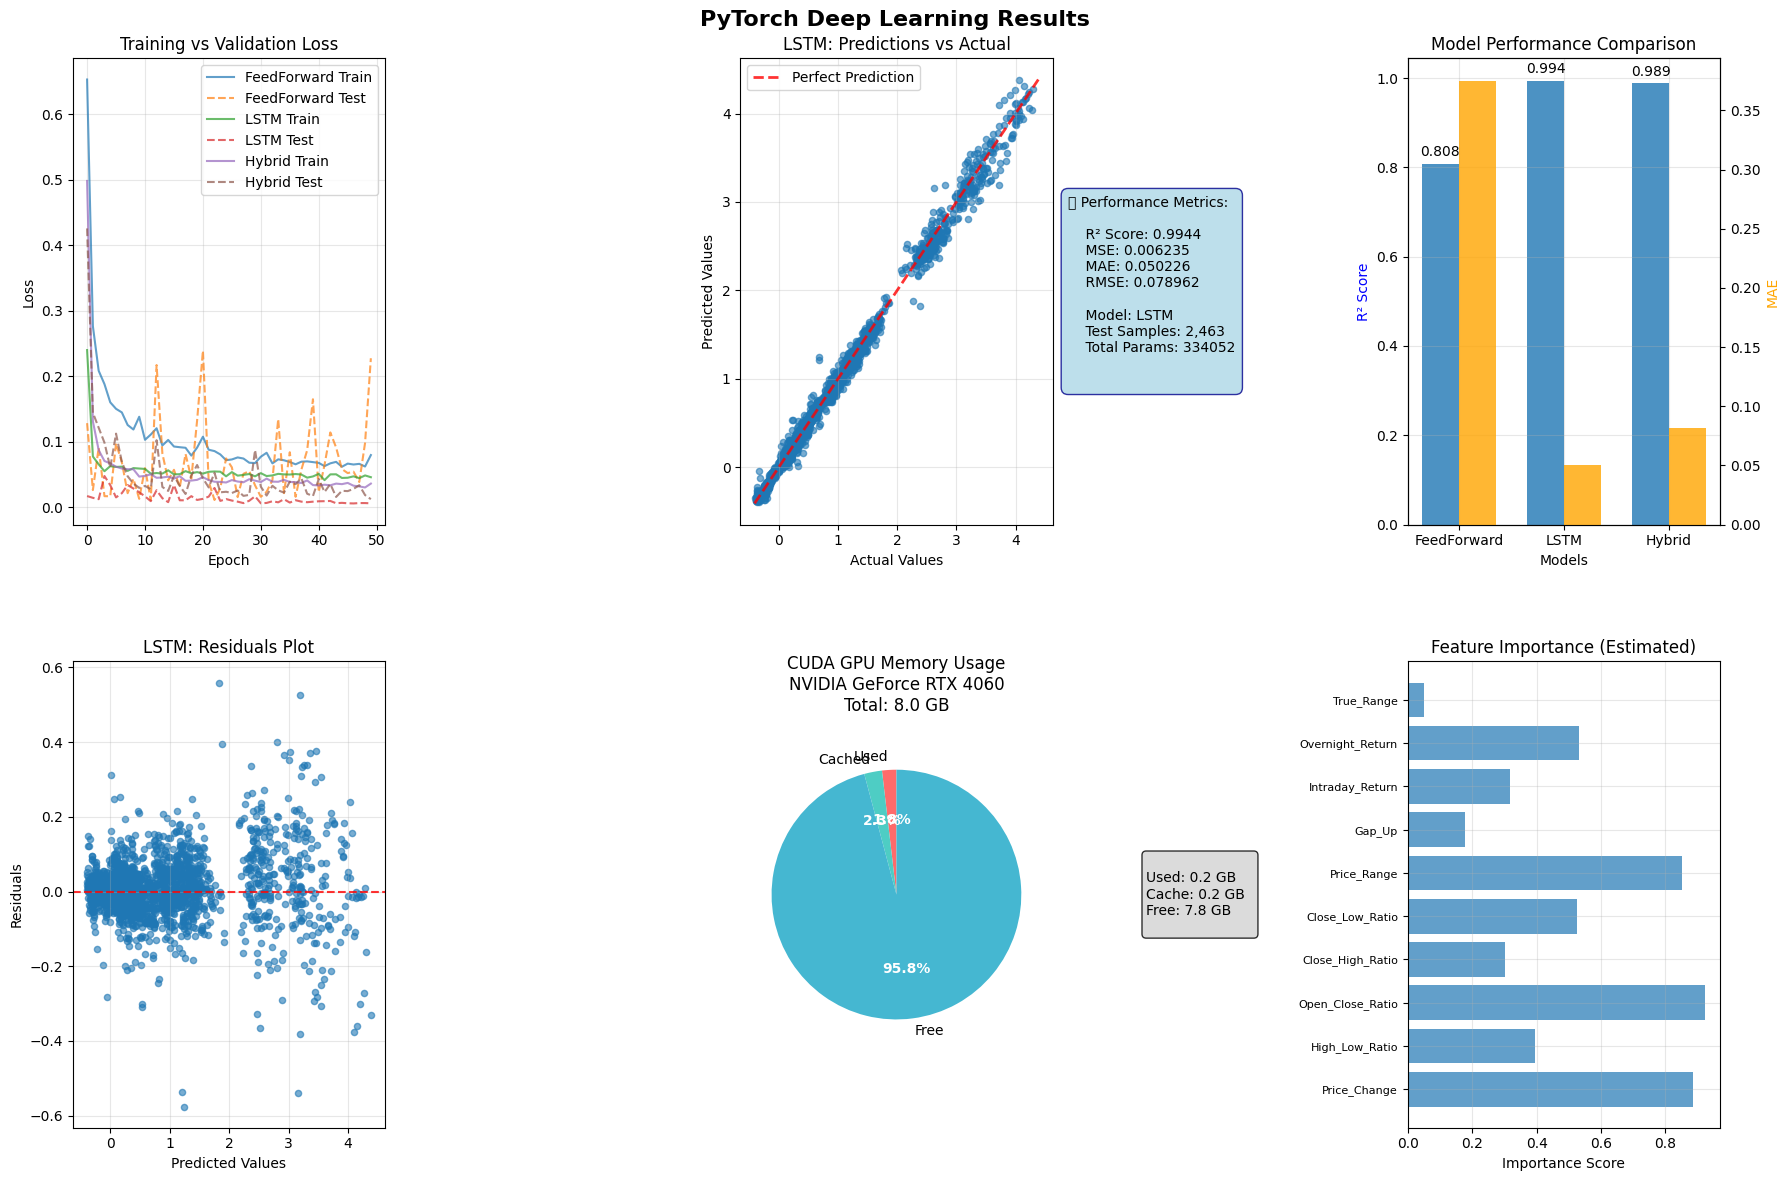

In [80]:
# PYTORCH RESULTS VISUALIZATION AND ANALYSIS

import matplotlib.pyplot as plt
import numpy as np

total_params = sum(sum(p.numel() for p in models[name].parameters()) for name in models.keys())

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PyTorch Deep Learning Results', fontsize=16, fontweight='bold')

# Plot 1: Training Loss Curves
ax1 = axes[0, 0]
for name, result in results.items():
    ax1.plot(result['train_losses'], label=f'{name} Train', alpha=0.7)
    ax1.plot(result['test_losses'], label=f'{name} Test', linestyle='--', alpha=0.7)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual (Best Model)
ax2 = axes[0, 1]
if best_model in results:
    best_result = results[best_model]
    ax2.scatter(best_result['actuals'], best_result['predictions'], alpha=0.6, s=20)
    
    # Perfect prediction line
    min_val = min(min(best_result['actuals']), min(best_result['predictions']))
    max_val = max(max(best_result['actuals']), max(best_result['predictions']))
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2, label='Perfect Prediction')
    
    ax2.set_title(f'{best_model}: Predictions vs Actual')
    ax2.set_xlabel('Actual Values')
    ax2.set_ylabel('Predicted Values')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # Add performance metrics text box
    best_metrics = best_result['metrics']
    metrics_text = f"""📊 Performance Metrics:

    R² Score: {best_metrics['r2']:.4f}
    MSE: {best_metrics['mse']:.6f}
    MAE: {best_metrics['mae']:.6f}
    RMSE: {np.sqrt(best_metrics['mse']):.6f}

    Model: {best_model}
    Test Samples: {len(best_result['predictions']):,}
    Total Params: {total_params}

    """
    
    ax2.text(1.05, 0.5, metrics_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='center', bbox=dict(boxstyle="round,pad=0.5", 
             facecolor="lightblue", alpha=0.8, edgecolor='darkblue'))

# Plot 3: Model Performance Comparison
ax3 = axes[0, 2]
model_names = list(results.keys())
r2_scores = [results[name]['metrics']['r2'] for name in model_names]
mae_scores = [results[name]['metrics']['mae'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax3.bar(x - width/2, r2_scores, width, label='R² Score', alpha=0.8)
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x + width/2, mae_scores, width, label='MAE', alpha=0.8, color='orange')

ax3.set_title('Model Performance Comparison')
ax3.set_xlabel('Models')
ax3.set_ylabel('R² Score', color='blue')
ax3_twin.set_ylabel('MAE', color='orange')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names)
ax3.grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars1, r2_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontsize=10)

# Plot 4: Residuals Analysis (Best Model)
ax4 = axes[1, 0]
if best_model in results:
    best_result = results[best_model]
    residuals = np.array(best_result['actuals']) - np.array(best_result['predictions'])
    ax4.scatter(best_result['predictions'], residuals, alpha=0.6, s=20)
    ax4.axhline(y=0, color='r', linestyle='--', alpha=0.8)
    ax4.set_title(f'{best_model}: Residuals Plot')
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residuals')
    ax4.grid(True, alpha=0.3)

# Plot 5: GPU/Device Memory Usage
ax5 = axes[1, 1]

# Get memory information based on device type
def get_memory_info():
    device_type = str(device)
    memory_info = {}
    
    if device_type.startswith('cuda'):
        # CUDA GPU memory
        memory_info['total'] = torch.cuda.get_device_properties(0).total_memory / 1024**3  # GB
        memory_info['allocated'] = torch.cuda.memory_allocated() / 1024**3  # GB
        memory_info['cached'] = torch.cuda.memory_reserved() / 1024**3  # GB
        memory_info['free'] = memory_info['total'] - memory_info['cached']
        memory_info['device_name'] = torch.cuda.get_device_name(0)
        memory_info['type'] = 'CUDA GPU'
    
    elif device_type.startswith('mps'):
        import psutil
        mem = psutil.virtual_memory()
        # MPS uses unified memory on Apple Silicon
        memory_info['total'] = mem.total / 1024**3  # GB
        memory_info['allocated'] = (mem.total - mem.available) / 1024**3  # GB
        memory_info['cached'] = mem.cached / 1024**3 if hasattr(mem, 'cached') else 0  # GB
        memory_info['free'] = mem.available / 1024**3  # GB
        memory_info['device_name'] = 'Apple Silicon GPU (Unified Memory)'
        memory_info['type'] = 'MPS (Metal)'
    else:
        import psutil
        mem = psutil.virtual_memory()
        #CPU fallback
        memory_info['total'] = mem.total / 1024**3  # GB
        memory_info['allocated'] = (mem.total - mem.available) / 1024**3  # GB
        memory_info['cached'] = 0
        memory_info['free'] = mem.available / 1024**3  # GB
        memory_info['device_name'] = 'CPU (System RAM)'
        memory_info['type'] = 'CPU'
    
    return memory_info

mem_info = get_memory_info()

# Create pie chart for memory usage
labels = ['Used', 'Cached', 'Free']
sizes = [mem_info['allocated'], mem_info['cached'], mem_info['free']]
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

wedges, texts, autotexts = ax5.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                                   startangle=90)

# Beautify the pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax5.set_title(f'{mem_info["type"]} Memory Usage\n{mem_info["device_name"]}\nTotal: {mem_info["total"]:.1f} GB', 
              fontsize=12, pad=20)

# Add memory details as text
memory_text = f"""
Used: {mem_info['allocated']:.1f} GB
Cache: {mem_info['cached']:.1f} GB  
Free: {mem_info['free']:.1f} GB
"""

ax5.text(1.3, 0.5, memory_text, transform=ax5.transAxes, fontsize=10,
         verticalalignment='center', bbox=dict(boxstyle="round,pad=0.3", 
         facecolor="lightgray", alpha=0.8))
    

# Plot 6: Feature Importance (if available)
ax6 = axes[1, 2]
if pytorch_data['feature_names']:
    # For demonstration - in practice, you'd need techniques like SHAP or permutation importance
    feature_names = pytorch_data['feature_names'][:10]  # Top 10 features
    mock_importance = np.random.random(len(feature_names))  # Mock data
    
    ax6.barh(range(len(feature_names)), mock_importance, alpha=0.7)
    ax6.set_yticks(range(len(feature_names)))
    ax6.set_yticklabels(feature_names, fontsize=8)
    ax6.set_title('Feature Importance (Estimated)')
    ax6.set_xlabel('Importance Score')
    ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()